# 📌 Extracción


In [81]:
import pandas as pd
import json

url = 'https://raw.githubusercontent.com/alura-cursos/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json'

In [82]:
df = pd.read_json(url)
df

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
...,...,...,...,...,...,...
7262,9987-LUTYD,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
7263,9992-RRAMN,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7264,9992-UJOEL,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7265,9993-LHIEB,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Two year', 'PaperlessBilling': '..."


# 🔧 Transformación

In [83]:
# Normalizar datos en distintas columnas
df_dict = df.to_dict(orient="records")
df = pd.json_normalize(df_dict, sep='_')
df

,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


#### Diccionario de datos

* `customerID`: unique identification number for each customer
* `Churn`: whether or not the customer left the company
* `gender`: gender (male and female)
* `SeniorCitizen`: whether the customer is 65 years old or older
* `Partner`: whether or not the customer has a partner
* `Dependents`: whether or not the customer has dependents
* `tenure`: number of months the customer has been under contract
* `PhoneService`: subscription to phone service
* `MultipleLines`: subscription to more than one phone line
* `InternetService`: subscription to an internet service provider
* `OnlineSecurity`: additional online security subscription
* `OnlineBackup`: additional online backup subscription
* `DeviceProtection`: additional device protection subscription
* `TechSupport`: additional technical support subscription with shorter waiting times
* `StreamingTV`: cable TV subscription
* `StreamingMovies`: movie streaming subscription
* `Contract`: type of contract
* `PaperlessBilling`: whether the customer prefers to receive bills online
* `PaymentMethod`: payment method
* `Charges.Monthly`: total cost of all customer services per month
* `Charges.Total`: total amount spent by the customer


In [84]:
# Revisar tipos de datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer_gender            7267 non-null   object 
 3   customer_SeniorCitizen     7267 non-null   int64  
 4   customer_Partner           7267 non-null   object 
 5   customer_Dependents        7267 non-null   object 
 6   customer_tenure            7267 non-null   int64  
 7   phone_PhoneService         7267 non-null   object 
 8   phone_MultipleLines        7267 non-null   object 
 9   internet_InternetService   7267 non-null   object 
 10  internet_OnlineSecurity    7267 non-null   object 
 11  internet_OnlineBackup      7267 non-null   object 
 12  internet_DeviceProtection  7267 non-null   object 
 13  internet_TechSupport       7267 non-null   objec

In [85]:
# Revisar dónde faltan datos
df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)
[(df == '').sum(), df.isna().sum()]

[customerID                     0
 Churn                        224
 customer_gender                0
 customer_SeniorCitizen         0
 customer_Partner               0
 customer_Dependents            0
 customer_tenure                0
 phone_PhoneService             0
 phone_MultipleLines            0
 internet_InternetService       0
 internet_OnlineSecurity        0
 internet_OnlineBackup          0
 internet_DeviceProtection      0
 internet_TechSupport           0
 internet_StreamingTV           0
 internet_StreamingMovies       0
 account_Contract               0
 account_PaperlessBilling       0
 account_PaymentMethod          0
 account_Charges_Monthly        0
 account_Charges_Total         11
 dtype: int64,
 customerID                   0
 Churn                        0
 customer_gender              0
 customer_SeniorCitizen       0
 customer_Partner             0
 customer_Dependents          0
 customer_tenure              0
 phone_PhoneService           0
 phone_Multiple

In [86]:
# Revisar si hay clientes repetidos
df['customerID'].nunique()

7267

In [87]:
# Revisar qué columnas tienen valores binarios 'Yes'/'No'
df.isin(['Yes', 'No']).all()

customerID                   False
Churn                        False
customer_gender              False
customer_SeniorCitizen       False
customer_Partner              True
customer_Dependents           True
customer_tenure              False
phone_PhoneService            True
phone_MultipleLines          False
internet_InternetService     False
internet_OnlineSecurity      False
internet_OnlineBackup        False
internet_DeviceProtection    False
internet_TechSupport         False
internet_StreamingTV         False
internet_StreamingMovies     False
account_Contract             False
account_PaperlessBilling      True
account_PaymentMethod        False
account_Charges_Monthly      False
account_Charges_Total        False
dtype: bool

In [88]:
# Revisar qué columnas tienen valores binarios 0/1
df.isin([0, 1]).all()

customerID                   False
Churn                        False
customer_gender              False
customer_SeniorCitizen        True
customer_Partner             False
customer_Dependents          False
customer_tenure              False
phone_PhoneService           False
phone_MultipleLines          False
internet_InternetService     False
internet_OnlineSecurity      False
internet_OnlineBackup        False
internet_DeviceProtection    False
internet_TechSupport         False
internet_StreamingTV         False
internet_StreamingMovies     False
account_Contract             False
account_PaperlessBilling     False
account_PaymentMethod        False
account_Charges_Monthly      False
account_Charges_Total        False
dtype: bool

# Resultados

+ 224 valores vacíos en `Churn`
+ 11 valores vacíos en `account_Charges_total`
+ Tipo de dato incorrecto en `account_Charges_Total` > valores numéricos
+ No hay clientes repetidos
+ Columnas con solo  1/0 o Yes/No values > boolean
    * `customer_SeniorCitizen`
    * `customer_Partner`
    * `customer_Dependents`
    * `phone_PhoneService`
    * `account_PaperlessBilling`


In [89]:
# Eliminar filas con Churn vacío
df_churn = df[df['Churn'] != ''].copy()

In [90]:
# Reemplazar vacíos en cargos por ceros y cambiar tipo de dato a float
df_churn['account_Charges_Total'] = df_churn['account_Charges_Total'].apply(lambda x: '0' if x == '' else x)
df_churn['account_Charges_Total'] = df_churn['account_Charges_Total'].astype(float)

In [91]:
# Convertir columnas con datos binarios a 0 y 1 para análisis de correlación
cols_to_binary = ['customer_Partner', 'customer_Dependents', 'phone_PhoneService', 'account_PaperlessBilling']
df_churn[cols_to_binary] = df_churn[cols_to_binary].apply(lambda col: col.map({'Yes': 1, 'No': 0}).astype('int'))

In [92]:
df_churn.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7043 non-null   object 
 1   Churn                      7043 non-null   object 
 2   customer_gender            7043 non-null   object 
 3   customer_SeniorCitizen     7043 non-null   int64  
 4   customer_Partner           7043 non-null   int64  
 5   customer_Dependents        7043 non-null   int64  
 6   customer_tenure            7043 non-null   int64  
 7   phone_PhoneService         7043 non-null   int64  
 8   phone_MultipleLines        7043 non-null   object 
 9   internet_InternetService   7043 non-null   object 
 10  internet_OnlineSecurity    7043 non-null   object 
 11  internet_OnlineBackup      7043 non-null   object 
 12  internet_DeviceProtection  7043 non-null   object 
 13  internet_TechSupport       7043 non-null   object 
 1

In [93]:
# Creando columna de cuentas diarias
df_churn['account_Charges_Daily'] = df_churn['account_Charges_Monthly'] / 30

In [94]:
# Renombrar columnas para su comprensión en nuevo df
df_renombrado = df_churn.rename(columns={'Churn':'Cancelación',
                                         'customer_gender':'Género',
                                         'customer_SeniorCitizen':'Adulto mayor',
                                         'customer_Partner':'Con pareja',
                                         'customer_Dependents':'Dependientes',
                                         'customer_tenure': 'Duración',
                                         'phone_PhoneService':'Servicio de teléfono',
                                         'phone_MultipleLines':'Líneas múltiples',
                                         'internet_InternetService':'Servicio de internet',
                                         'internet_OnlineSecurity':'Seguridad en línea',
                                         'internet_OnlineBackup':'Backup en línea',
                                         'internet_DeviceProtection':'Protección de dispositivos',
                                         'internet_TechSupport':'Soporte técnico',
                                         'internet_StreamingTV':'Streaming TV',
                                         'internet_StreamingMovies':'Streaming películas',
                                         'account_Contract':'Contrato',
                                         'account_PaperlessBilling':'Facturación electrónica',
                                         'account_PaymentMethod':'Método de pago',
                                         'account_Charges_Monthly':'Cargos mensuales',
                                         'account_Charges_Total':'Cargos totales',
                                         'account_Charges_Daily':'Cargos diarios'
                                         })

In [95]:
# Conversión de valores binarios en columna Churn también
df_renombrado['Cancelación'] = df_renombrado['Cancelación'].replace({'Yes' : 1, 'No' : 0}).astype('int')

C:\Users\mauri\AppData\Local\Temp\ipykernel_3912\614718228.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_renombrado['Cancelación'] = df_renombrado['Cancelación'].replace({'Yes' : 1, 'No' : 0}).astype('int')


In [97]:
# Buscar datos categóricos para renombrar para su comprensión
for col in df_renombrado.columns:
    if 2 < len(df_renombrado[col].unique()) < 10:
        print(col, df_renombrado[col].unique())

Líneas múltiples ['No' 'Yes' 'No phone service']
Servicio de internet ['DSL' 'Fiber optic' 'No']
Seguridad en línea ['No' 'Yes' 'No internet service']
Backup en línea ['Yes' 'No' 'No internet service']
Protección de dispositivos ['No' 'Yes' 'No internet service']
Soporte técnico ['Yes' 'No' 'No internet service']
Streaming TV ['Yes' 'No' 'No internet service']
Streaming películas ['No' 'Yes' 'No internet service']
Contrato ['One year' 'Month-to-month' 'Two year']
Método de pago ['Mailed check' 'Electronic check' 'Credit card (automatic)'
 'Bank transfer (automatic)']


In [98]:
# Renombrar valores de servicios internet
df_renombrado['Servicio de internet'] = df_renombrado['Servicio de internet'].replace({'DSL':'DSL', 'Fiber optic':'Fibra óptica', 'No':'No'})
columnas_internet = ['Seguridad en línea', 'Backup en línea', 'Protección de dispositivos', 'Soporte técnico', 'Streaming TV', 'Streaming películas']
df_renombrado[columnas_internet] = df_renombrado[columnas_internet].replace({'Yes' : 'Sí', 'No' : 'No', 'No internet service':'Sin servicio de internet'})

In [99]:
# Renombrar valores de servicios teléfono
df_renombrado['Líneas múltiples'] = df_renombrado['Líneas múltiples'].replace({'Yes' : 'Sí', 'No' : 'No', 'No phone service':'Sin servicio telefónico'})

In [100]:
# Renombrar tipos de contrato
df_renombrado['Contrato'] = df_renombrado['Contrato'].replace({'One year':'Un año', 'Month-to-month':'Mes a mes', 'Two year':'Dos años'})

In [101]:
# Renombrar métodos de pago
df_renombrado['Método de pago'] = df_renombrado['Método de pago'].replace({'Mailed check' :'Cheque por correo',
                                                                 'Electronic check':'Cheque electrónico',
                                                                 'Credit card (automatic)':'Tarjeta de crédito (automático)',
                                                                 'Bank transfer (automatic)':'Transferencia bancaria (automático)'})

In [102]:
# Renombrar género
df_renombrado['Género'] = df_renombrado['Género'].replace({'Male' :'Hombre', 'Female':'Mujer'})

# 📊 Carga y análisis

In [103]:
# Descripción rápida de los datos numéricos
df_renombrado.describe()

,Cancelación,Adulto mayor,Con pareja,Dependientes,Duración,Servicio de teléfono,Facturación electrónica,Cargos mensuales,Cargos totales,Cargos diarios
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.265370,0.162147,0.483033,0.299588,32.371149,0.903166,0.592219,64.761692,2279.734304,2.158723
std,0.441561,0.368612,0.499748,0.458110,24.559481,0.295752,0.491457,30.090047,2266.794470,1.003002
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,0.000000,0.608333
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,35.500000,398.550000,1.183333
50%,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,70.350000,1394.550000,2.345000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,89.850000,3786.600000,2.995000
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000,3.958333


In [104]:
import seaborn as sns
import matplotlib.pyplot as plt

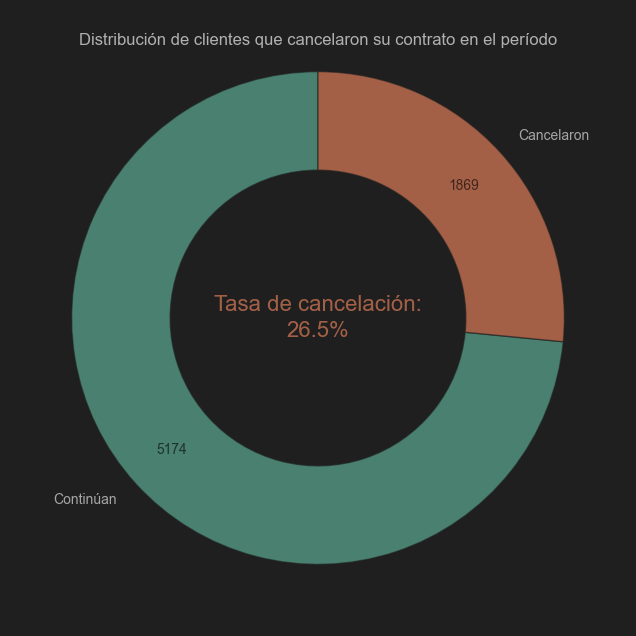

In [193]:
cancelaciones = (df_renombrado['Cancelación'].value_counts().rename(index={1: 'Cancelaron', 0: 'Continúan'}))

fig, ax = plt.subplots(figsize=(8,8), facecolor='#1f1f1f')

colors = sns.color_palette('Set2', n_colors=len(cancelaciones))

wedges, texts, autotexts = ax.pie(
    cancelaciones,
    labels=cancelaciones.index,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(width=0.4, edgecolor='#1f1f1f', alpha=0.6),
    pctdistance = 0.8,
    colors=colors
)

for autotext, value in zip(autotexts, cancelaciones):
    autotext.set_text(f'{value}')

ax.text(x=0, y=0,
        horizontalalignment='center',
        verticalalignment='center',
        s=f'Tasa de cancelación:\n{100 * cancelaciones.loc["Cancelaron"] / cancelaciones.sum():.1f}%',
        color=sns.color_palette('Set2')[1],
        size=16,
        linespacing=1.4,
        alpha=0.6
        )

for t in texts:
    t.set_color('white')
    t.set_alpha(0.6)

for t in autotexts:
    t.set_color('black')
    t.set_alpha(0.6)

ax.set_title('Distribución de clientes que cancelaron su contrato en el período', y=0.93, color='white', alpha=0.65)

plt.show()

In [106]:
import numpy as np

In [113]:
# Distribución de la evasión por perfil del cliente
df_clientes = pd.pivot_table(df_renombrado,
                             values='Cancelación',
                             index=['Género', 'Con pareja', 'Adulto mayor', 'Dependientes'],
                             aggfunc=['count', 'mean']
                             )

df_clientes.columns = [f'{a}_{b}' for a,b in df_clientes.columns]
df_clientes = df_clientes.rename(columns={'mean_Cancelación':'Tasa de cancelación', 'count_Cancelación' : 'Cancelaciones'}, index={1:'Sí', 0:'No'})

df_clientes_estilo = df_clientes.style
df_clientes_estilo.format({'Tasa de cancelación':'{:.1%}'})
df_clientes_estilo.background_gradient(cmap='RdYlGn_r', subset=['Tasa de cancelación'])

df_clientes_estilo

In [257]:
df_renombrado.sample(10)

,customerID,Cancelación,Género,Adulto mayor,Con pareja,Dependientes,Duración,Servicio de teléfono,Líneas múltiples,Servicio de internet,...,Soporte técnico,Streaming TV,Streaming películas,Contrato,Facturación electrónica,Método de pago,Cargos mensuales,Cargos totales,Cargos diarios,Total_Servicios
5916,8080-DDEMJ,1,Hombre,1,0,0,1,1,No,DSL,...,No,No,No,Mes a mes,0,Cheque electrónico,45.10,45.10,1.503333,2
6376,8756-RDDLT,0,Mujer,0,0,0,68,0,Sin servicio telefónico,DSL,...,Sí,No,Sí,Mes a mes,0,Cheque electrónico,44.95,3085.35,1.498333,4
241,0363-QJVFX,1,Hombre,0,0,0,32,1,Sí,Fibra óptica,...,Sí,Sí,Sí,Mes a mes,1,Tarjeta de crédito (automático),108.15,3432.90,3.605000,8
5671,7748-UMTRK,0,Mujer,1,0,1,30,1,Sí,Fibra óptica,...,Sí,Sí,Sí,Mes a mes,1,Cheque electrónico,101.30,2974.50,3.376667,6
1693,2400-FEQME,0,Hombre,0,1,1,55,1,No,No,...,Sin servicio de internet,Sin servicio de internet,Sin servicio de internet,Dos años,0,Cheque por correo,20.50,1177.95,0.683333,1
5286,7225-CBZPL,0,Hombre,1,1,0,17,1,Sí,Fibra óptica,...,No,Sí,Sí,Mes a mes,1,Cheque electrónico,94.80,1563.90,3.160000,5
5139,7016-NVRIC,0,Hombre,1,1,0,29,1,No,Fibra óptica,...,No,No,Sí,Un año,0,Transferencia bancaria (automático),90.10,2656.70,3.003333,5
6869,9481-IEBZY,0,Hombre,1,1,0,72,1,Sí,Fibra óptica,...,Sí,Sí,Sí,Mes a mes,1,Tarjeta de crédito (automático),112.90,8061.50,3.763333,9
5365,7322-OCWHC,0,Hombre,1,1,0,72,1,Sí,Fibra óptica,...,Sí,No,No,Dos años,1,Transferencia bancaria (automático),93.05,6735.05,3.101667,7
4348,5968-HYJRZ,0,Hombre,0,1,1,47,1,Sí,No,...,Sin servicio de internet,Sin servicio de internet,Sin servicio de internet,Dos años,0,Cheque por correo,24.55,1160.45,0.818333,2


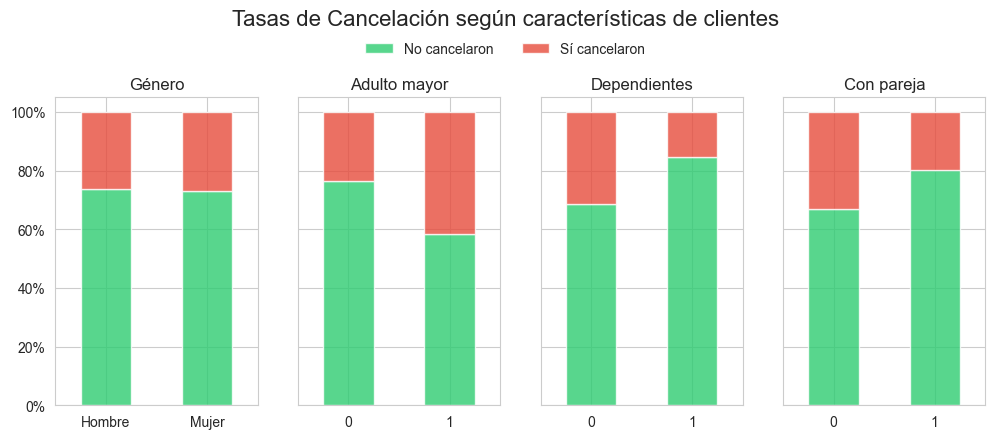

In [223]:
# Comparación de clientes según sus características
import matplotlib.ticker as mtick
caracteristicas_clientes = ['Género', 'Adulto mayor', 'Dependientes', 'Con pareja']

# Barras apiladas para cada categoría
fig, axes = plt.subplots(nrows=1, ncols=len(caracteristicas_clientes), figsize=(12, 4), sharey=True)
fig.suptitle('Tasas de Cancelación según características de clientes', fontsize=16, y=1.1)

for i, col in enumerate(caracteristicas_clientes):

    df_plot = pd.crosstab(df_renombrado[col], df['Churn'], normalize='index') * 100
    df_plot.plot(kind='bar', stacked=True, ax=axes[i], color=['#2ecc71', '#e74c3c'], alpha=0.8, legend=False)

    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].yaxis.set_major_formatter(mtick.PercentFormatter())
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=0)

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(['No cancelaron', 'Sí cancelaron'], bbox_to_anchor=(0.5, 1.05),
           loc='upper center', ncol=2, frameon=False)
plt.show()

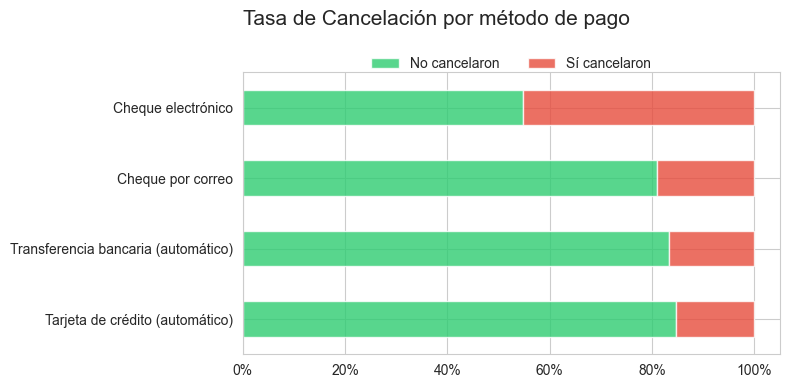

In [222]:
# Distribución de la evasión por método de pago

tabla_pago = pd.crosstab(df_renombrado['Método de pago'],
                         df_renombrado['Cancelación'],
                         normalize='index') * 100

# Ordenar de mayor a menor tasa de cancelación para que el gráfico sea más revelador
tabla_pago = tabla_pago.sort_values(by=1, ascending=True)

ax = tabla_pago.plot(kind='barh',
                     stacked=True,
                     figsize=(8, 4),
                     color=['#2ecc71', '#e74c3c'],
                     legend=False,
                     alpha=0.8)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())

plt.title('Tasa de Cancelación por método de pago', loc='left', fontsize=15, pad=20, y=1.07)
plt.ylabel('')
plt.legend(['No cancelaron', 'Sí cancelaron'], bbox_to_anchor=(0.5, 1.1),
           loc='upper center', ncol=2, frameon=False)

plt.tight_layout()
plt.show()

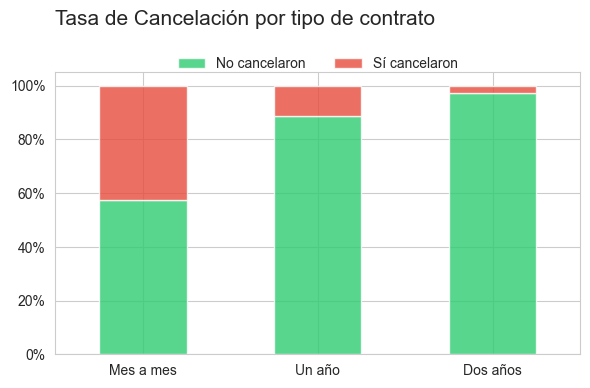

In [226]:
# Distribución de la evasión por duración de contrato
tabla_contrato = pd.crosstab(df_renombrado['Contrato'],
                             df_renombrado['Cancelación'],
                             normalize='index') * 100

tabla_contrato = tabla_contrato.sort_values(by=1, ascending=False)

# 3. Graficar en barras verticales (kind='bar')
ax = tabla_contrato.plot(kind='bar',
                         stacked=True,
                         figsize=(6, 4),
                         color=['#2ecc71', '#e74c3c'],
                         legend=False,
                         alpha=0.8)

# Configuración de títulos y etiquetas siguiendo tu diseño
plt.title('Tasa de Cancelación por tipo de contrato', loc='left', fontsize=15, pad=20, y=1.07)
plt.xlabel('')
plt.xticks(rotation=0) # Asegura que los nombres de los contratos se lean horizontalmente

# El formateador de porcentaje ahora va en el eje Y
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

# Leyenda global superior
plt.legend(['No cancelaron', 'Sí cancelaron'], bbox_to_anchor=(0.5, 1.1),
           loc='upper center', ncol=2, frameon=False)

plt.tight_layout()
plt.show()

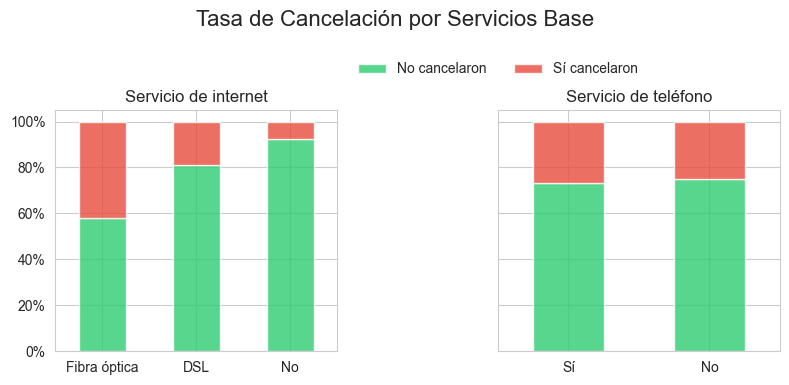

In [249]:
# Distribución de la evasión según  servicio de internet y de teléfono
servicios_principales = ['Servicio de internet', 'Servicio de teléfono']
mapeo_tel = {0: 'No', 1: 'Sí', '0': 'No', '1': 'Sí'}

fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharey=True)
fig.suptitle('Tasa de Cancelación por Servicios Base', fontsize=16, y=0.95)

for i, col in enumerate(servicios_principales):
    df_temp = df_renombrado.copy()
    if col == 'Servicio de teléfono':
        df_temp[col] = df_temp[col].replace(mapeo_tel)

    tabla = pd.crosstab(df_temp[col], df_temp['Cancelación'], normalize='index') * 100
    tabla = tabla.sort_values(by=1, ascending=False)

    tabla.plot(kind='bar', stacked=True, ax=axes[i],
               color=['#2ecc71', '#e74c3c'], alpha=0.8, legend=False)

    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=0)
    axes[i].yaxis.set_major_formatter(mtick.PercentFormatter())

plt.legend(['No cancelaron', 'Sí cancelaron'], bbox_to_anchor=(0, 1.25),
           loc='upper center', ncol=2, frameon=False)

plt.tight_layout()
plt.show()

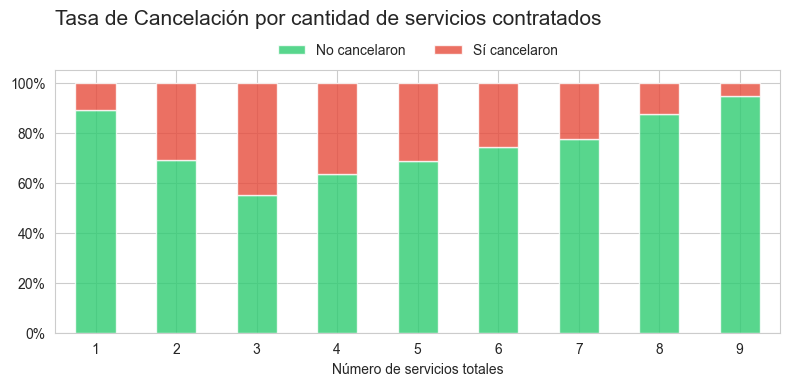

In [255]:
# Distribución de la evasión según  cantidad de servicios extra
servicios_extra = ['Protección de dispositivos', 'Seguridad en línea', 'Backup en línea',
                   'Soporte técnico', 'Streaming TV', 'Streaming películas']

# Suma: Internet (si tiene) + Teléfono (si tiene) + Líneas múltiples + Extras
df_renombrado['Total_Servicios'] = (
    (df_renombrado['Servicio de internet'] != 'No').astype(int) +
    df_renombrado['Servicio de teléfono'].astype(int) +
    (df_renombrado['Líneas múltiples'] == 'Sí').astype(int) +
    df_renombrado[servicios_extra].apply(lambda x: x == 'Sí').sum(axis=1)
)

tabla_suma = pd.crosstab(df_renombrado['Total_Servicios'],
                         df_renombrado['Cancelación'], normalize='index') * 100

ax = tabla_suma.plot(kind='bar', stacked=True, figsize=(8, 4),
                     color=['#2ecc71', '#e74c3c'], alpha=0.8, legend=False)

plt.title('Tasa de Cancelación por cantidad de servicios contratados',
          loc='left', fontsize=15, pad=20, y=1.07)
plt.xlabel('Número de servicios totales')
plt.xticks(rotation=0)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

plt.legend(['No cancelaron', 'Sí cancelaron'], bbox_to_anchor=(0.5, 1.15),
           loc='upper center', ncol=2, frameon=False)

plt.tight_layout()
plt.show()

In [250]:
df_renombrado

,customerID,Cancelación,Género,Adulto mayor,Con pareja,Dependientes,Duración,Servicio de teléfono,Líneas múltiples,Servicio de internet,...,Protección de dispositivos,Soporte técnico,Streaming TV,Streaming películas,Contrato,Facturación electrónica,Método de pago,Cargos mensuales,Cargos totales,Cargos diarios
0,0002-ORFBO,0,Mujer,0,1,1,9,1,No,DSL,...,No,Sí,Sí,No,Un año,1,Cheque por correo,65.60,593.30,2.186667
1,0003-MKNFE,0,Hombre,0,0,0,9,1,Sí,DSL,...,No,No,No,Sí,Mes a mes,0,Cheque por correo,59.90,542.40,1.996667
2,0004-TLHLJ,1,Hombre,0,0,0,4,1,No,Fibra óptica,...,Sí,No,No,No,Mes a mes,1,Cheque electrónico,73.90,280.85,2.463333
3,0011-IGKFF,1,Hombre,1,1,0,13,1,No,Fibra óptica,...,Sí,No,Sí,Sí,Mes a mes,1,Cheque electrónico,98.00,1237.85,3.266667
4,0013-EXCHZ,1,Mujer,1,1,0,3,1,No,Fibra óptica,...,No,Sí,Sí,No,Mes a mes,1,Cheque por correo,83.90,267.40,2.796667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,0,Mujer,0,0,0,13,1,No,DSL,...,No,Sí,No,No,Un año,0,Cheque por correo,55.15,742.90,1.838333
7263,9992-RRAMN,1,Hombre,0,1,0,22,1,Sí,Fibra óptica,...,No,No,No,Sí,Mes a mes,1,Cheque electrónico,85.10,1873.70,2.836667
7264,9992-UJOEL,0,Hombre,0,0,0,2,1,No,DSL,...,No,No,No,No,Mes a mes,1,Cheque por correo,50.30,92.75,1.676667
7265,9993-LHIEB,0,Hombre,0,1,1,67,1,No,DSL,...,Sí,Sí,No,Sí,Dos años,0,Cheque por correo,67.85,4627.65,2.261667


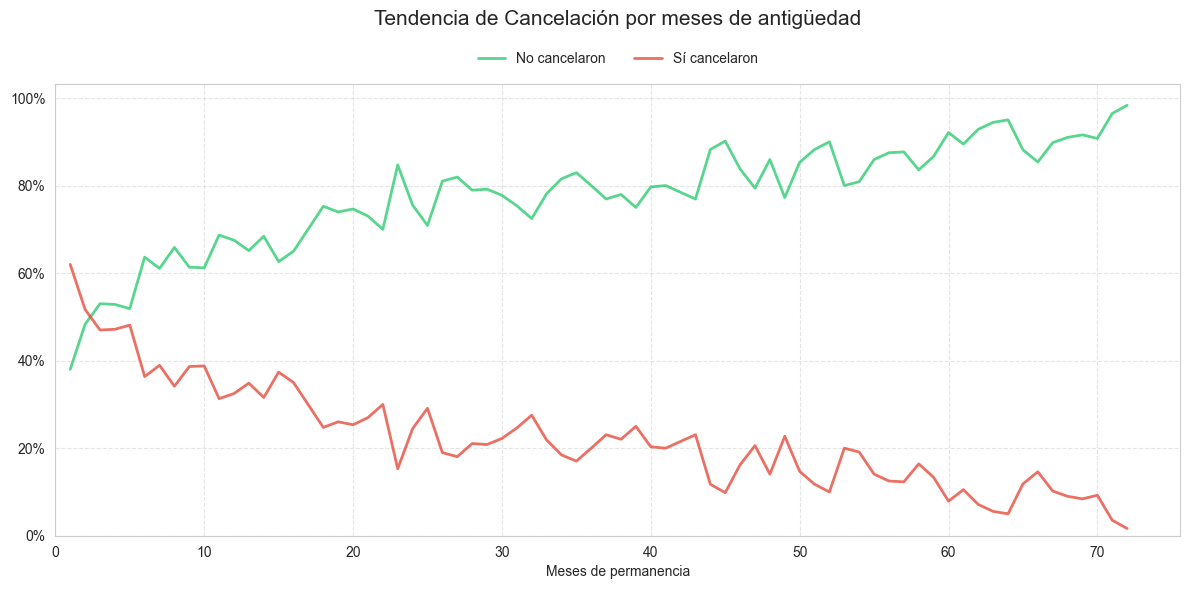

In [292]:
tabla_duracion = pd.crosstab(df_renombrado['Duración'],
                             df_renombrado['Cancelación'],
                             normalize='index') * 100

ax = tabla_duracion.iloc[1:].plot(kind='line',
                         figsize=(12, 6),
                         color=['#2ecc71', '#e74c3c'],
                         alpha=0.8,
                         linewidth=2)

plt.title('Tendencia de Cancelación por meses de antigüedad', loc='center', fontsize=15, pad=20, y=1.07)
plt.xlabel('Meses de permanencia')
plt.ylabel('')

ax.yaxis.set_major_formatter(mtick.PercentFormatter())

plt.legend(['No cancelaron', 'Sí cancelaron'], bbox_to_anchor=(0.5, 1.1),
           loc='upper center', ncol=2, frameon=False)
plt.xlim(left=0)
plt.ylim(bottom=0)

plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

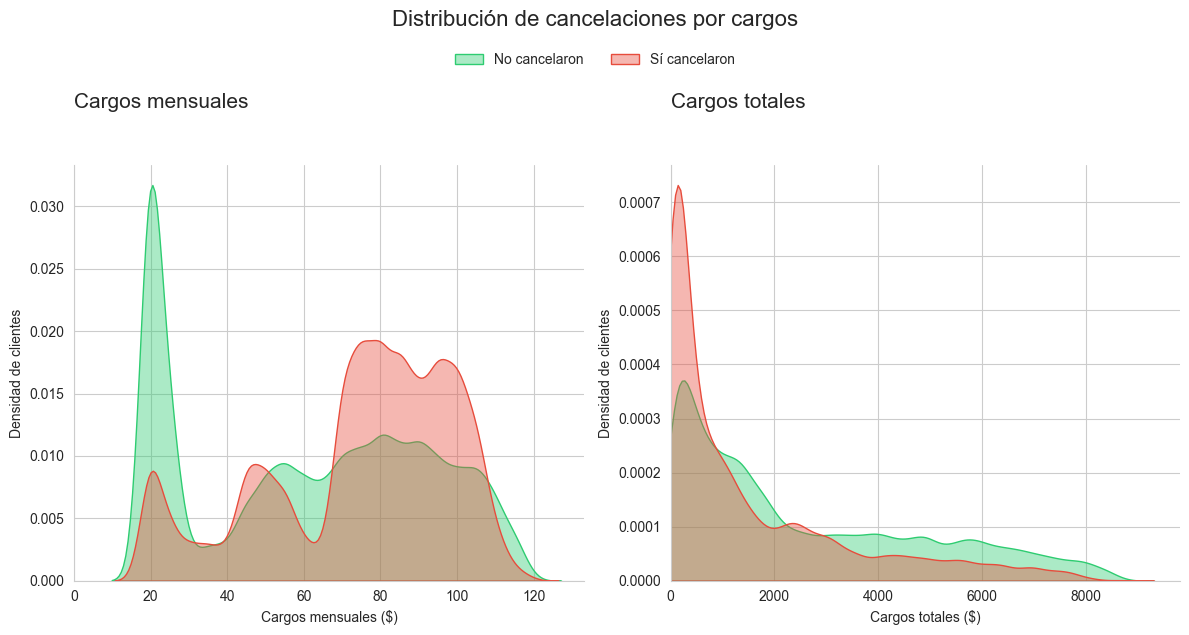

In [299]:
# Distribución de cancelaciones por cargos mensuales y totales
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

columnas_gasto = ['Cargos mensuales', 'Cargos totales']

for i, col in enumerate(columnas_gasto):
    sns.kdeplot(df_renombrado[df_renombrado['Cancelación'] == 0][col],
                bw_adjust=0.5, ax=axes[i], fill=True,
                color='#2ecc71', alpha=0.4, label='No cancelaron')

    sns.kdeplot(df_renombrado[df_renombrado['Cancelación'] == 1][col],
                bw_adjust=0.5, ax=axes[i], fill=True,
                color='#e74c3c', alpha=0.4, label='Sí cancelaron')

    axes[i].set_title(col, loc='left', fontsize=15, pad=20, y=1.07)
    axes[i].set_xlabel(f'{col} ($)')
    axes[i].set_ylabel('Densidad de clientes')
    axes[i].set_xlim(left=0) # Empezar en 0,0

    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
fig.suptitle('Distribución de cancelaciones por cargos', fontsize=16, y=1.05)
fig.legend(handles, ['No cancelaron', 'Sí cancelaron'],
           bbox_to_anchor=(0.5, 1), loc='upper center',
           ncol=2, frameon=False)

plt.tight_layout()
plt.show()